# Импортируем нужные библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
from scipy.integrate import solve_ivp
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score
import pysindy as ps
from pysindy.feature_library import GeneralizedLibrary, PolynomialLibrary, FourierLibrary

# Читаем и обрабатываем исходные данные 

In [2]:
# Читаем файл с данными по эволюции упрочняющей фазы
df = pd.read_csv('../data/Inconel_18_demo.csv', sep=',')
#df.columns = ['time', 'vf_gp', 'vf_gpp', 'vf_gp_total', 'vf_gpp_total', 'gs_gp', 'gs_gpp']
print(df.head(5))

   'Time(min)'  Gamma` isothermal  Gamma" isothermal  Gamma` total  \
0     0.000000                0.0                0.0           0.0   
1     0.001667                0.0                0.0           0.0   
2     0.003333                0.0                0.0           0.0   
3     0.005000                0.0                0.0           0.0   
4     0.006667                0.0                0.0           0.0   

   Gamma" total  Gamma` isothermal Grain Size  Gamma" isothermal Grain Size  
0           0.0                           0.0                           0.0  
1           0.0                           0.0                           0.0  
2           0.0                           0.0                           0.0  
3           0.0                           0.0                           0.0  
4           0.0                           0.0                           0.0  


In [3]:
# Выкинем лишние данные
df = df.drop(columns=['Gamma` total', 'Gamma" total'])
# переименуем колонки
# time - время
# vf_gp - volume fraction gamma prime
# vf_gpp - volume fraction gamma prime prime
# gs_gp - grain size gamma prime
# gs_gpp - grain size gamma prime prime 
df.columns = ['time', 'vf_gp', 'vf_gpp', 'gs_gp', 'gs_gpp']
print(df.head(1045))

          time     vf_gp    vf_gpp     gs_gp    gs_gpp
0     0.000000  0.000000  0.000000  0.000000  0.000000
1     0.001667  0.000000  0.000000  0.000000  0.000000
2     0.003333  0.000000  0.000000  0.000000  0.000000
3     0.005000  0.000000  0.000000  0.000000  0.000000
4     0.006667  0.000000  0.000000  0.000000  0.000000
...        ...       ...       ...       ...       ...
1040  2.178000  0.000000  0.000003  0.000000  0.494277
1041  2.223000  0.000001  0.000003  0.383973  0.538429
1042  2.273000  0.000002  0.000004  0.418273  0.586523
1043  2.327000  0.000002  0.000005  0.455637  0.638911
1044  2.386000  0.000003  0.000007  0.496337  0.695975

[1045 rows x 5 columns]


# Визуализируем графики

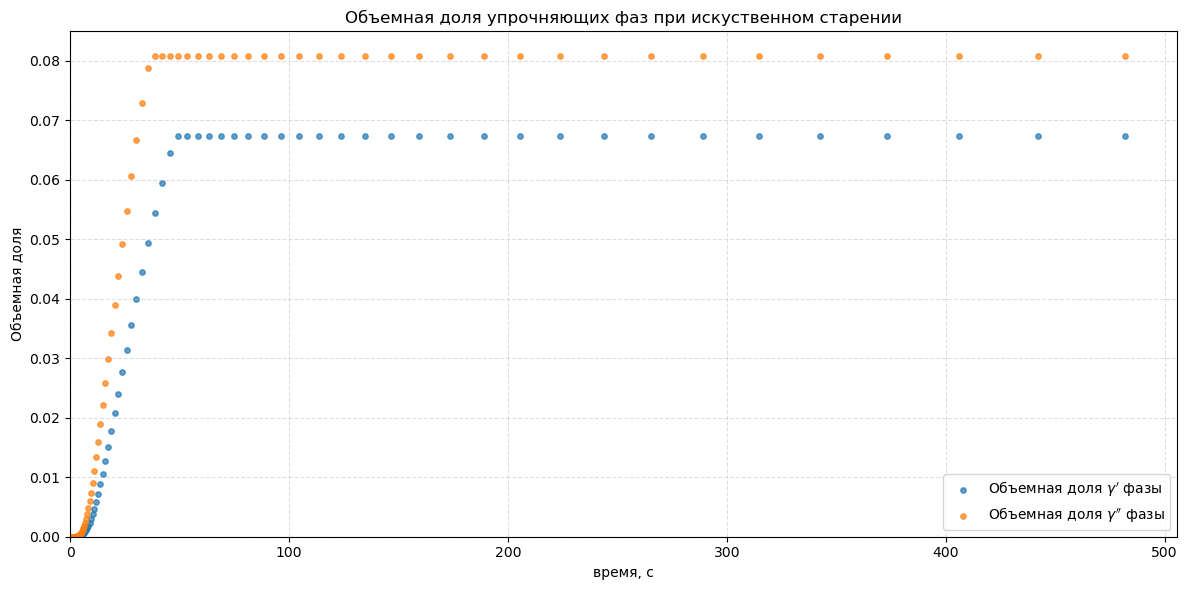

In [4]:
plt.figure(figsize=(12, 6))

# s=15 — размер точек (по умолчанию ~20-30, можно ставить 5-50)
plt.scatter(df['time'], df['vf_gp'], label=r"Объемная доля $\gamma'$ фазы",  s=15, alpha=0.7)
plt.scatter(df['time'], df['vf_gpp'], label=r"Объемная доля $\gamma''$ фазы", s=15, alpha=0.7)

# Начало осей с 0
plt.xlim(left=0)   # ось X от 0
plt.ylim(bottom=0) # ось Y от 0


plt.xlabel('время, с')
plt.ylabel('Объемная доля')
plt.title('Объемная доля упрочняющих фаз при искуственном старении')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

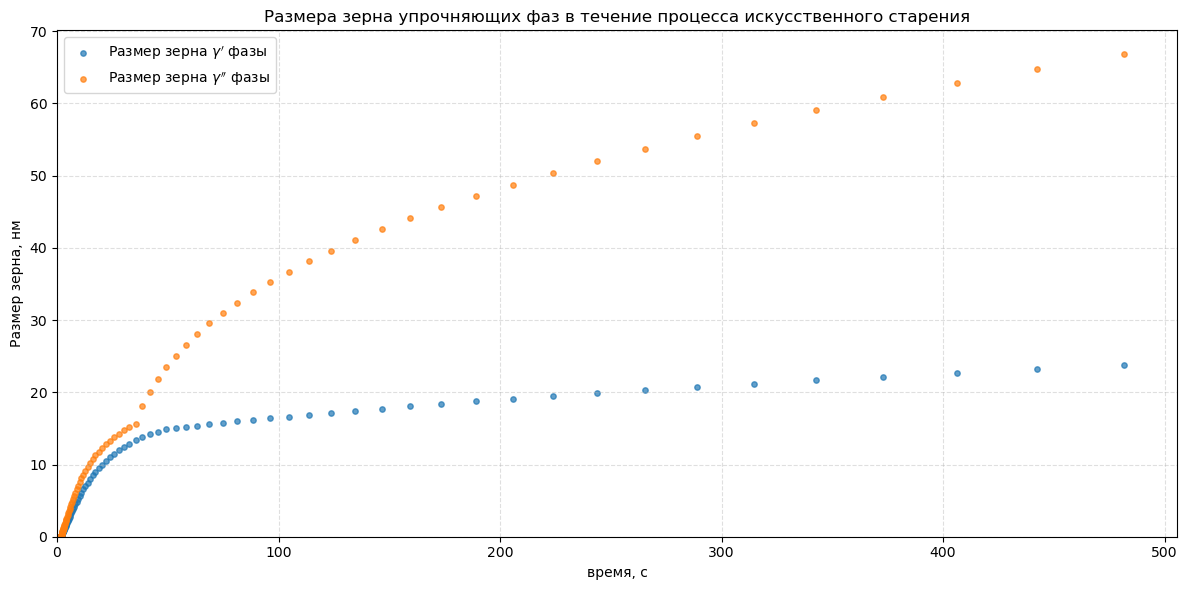

In [5]:
plt.figure(figsize=(12, 6))

# s=15 — размер точек (по умолчанию ~20-30, можно ставить 5-50)
plt.scatter(df['time'], df['gs_gp'], label=r"Размер зерна $\gamma'$ фазы",  s=15, alpha=0.7)
plt.scatter(df['time'], df['gs_gpp'], label=r"Размер зерна $\gamma''$ фазы", s=15, alpha=0.7)

# Начало осей с 0
plt.xlim(left=0)   # ось X от 0
plt.ylim(bottom=0) # ось Y от 0


plt.xlabel('время, с')
plt.ylabel('Размер зерна, нм')
plt.title('Размера зерна упрочняющих фаз в течение процесса искусственного старения')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Переходим к кодированному масштабу

In [6]:
# Создаем отдельные переменные в виде np array для времени и для функций
t = df['time'].values
X_raw = df[['vf_gp', 'vf_gpp', 'gs_gp', 'gs_gpp']].values
# Масштабируем все данные от 0.0001 до 0.9999
scaler = MinMaxScaler(feature_range=(0.0001, 0.9999))
X_scaled = scaler.fit_transform(X_raw)


# Вычисляем производную для каждой переменной и строим график производной

In [7]:
# Вычисление производных с маскированием

def compute_derivatives_with_masking(data, t, threshold=0.0001):
    """
    Вычисляет производные с маскированием инкубационных периодов.
    
    threshold: минимальное значение переменной (data > threshold)
    threshold2: минимальное значение производной (|dx/dt| > threshold2)
    """
    n_vars = data.shape[1] 
    x_dot = np.zeros_like(data)
    masks = np.zeros_like(data, dtype=bool)  # по умолчанию все точки неактивны
    
    for i in range(n_vars):
        # Сглаживание
        #smooth = savgol_filter(data[:, i], window_length=25, polyorder=2)
        smooth = gaussian_filter1d(data[:, i], sigma=2)

        
        # Производная
        x_dot[:, i] = np.gradient(smooth, t)
        
        # Два условия активности:
        # 1. Значение переменной > threshold
        # 2. Модуль производной > threshold2
        active = data[:, i] > threshold 
       

        
        # Распространяем маску вперёд: если фаза "проснулась", остаётся активной
        for j in range(1, len(active)):
            if active[j-1]:
                active[j] = True      
        
        masks[:, i] = active
    
    return x_dot, masks

# Вызов функции с двумя порогами
x_dot_scaled, masks = compute_derivatives_with_masking(X_scaled, t, threshold=0.0001)

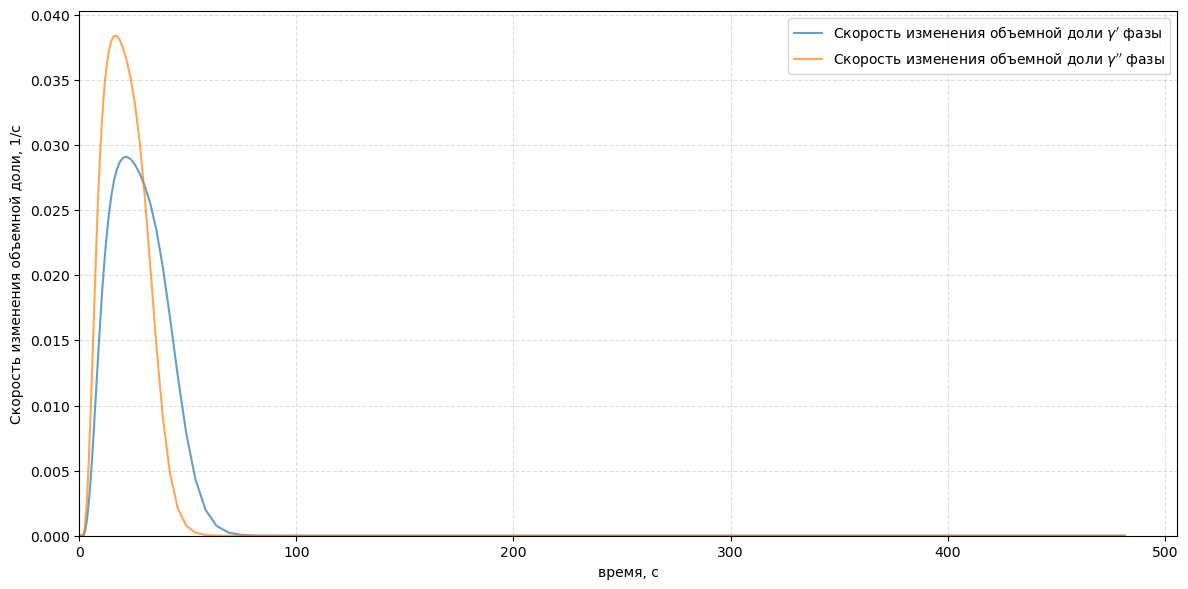

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(t, x_dot_scaled[:,0], label=r"Скорость изменения объемной доли $\gamma'$ фазы",  alpha=0.7)
plt.plot(t, x_dot_scaled[:,1], label=r"Скорость изменения объемной доли $\gamma''$ фазы", alpha=0.7)

# Начало осей с 0
plt.xlim(left=0)   # ось X от 0
plt.ylim(bottom=0) # ось Y от 0


plt.xlabel('время, с')
plt.ylabel('Скорость изменения объемной доли, 1/с')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

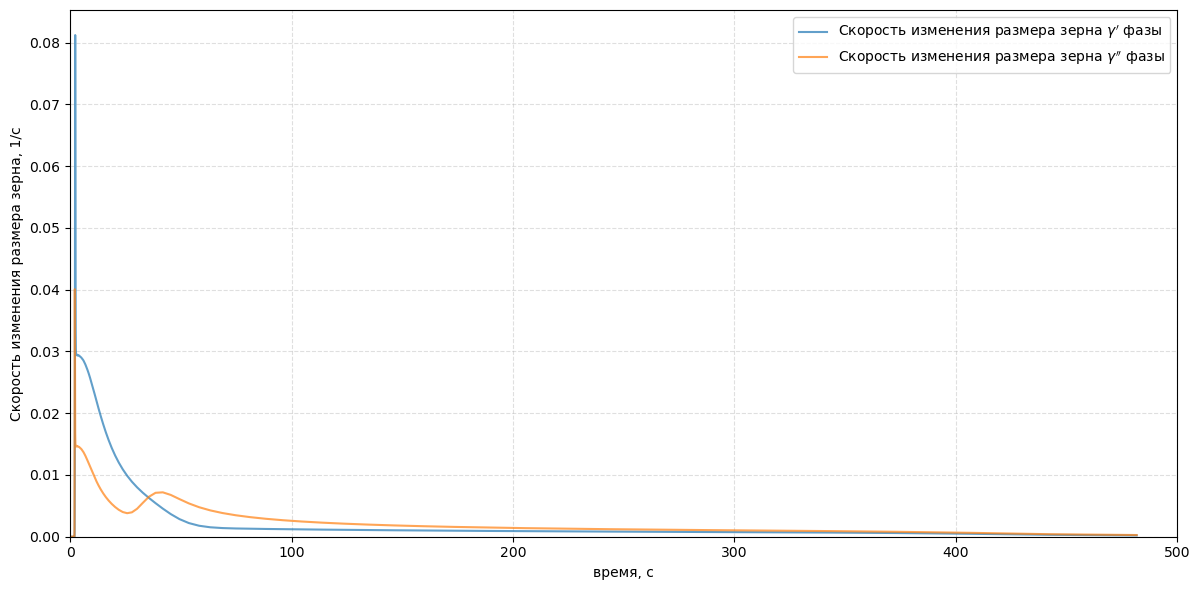

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(t, x_dot_scaled[:,2], label=r"Скорость изменения размера зерна $\gamma'$ фазы",  alpha=0.7)
plt.plot(t, x_dot_scaled[:,3], label=r"Скорость изменения размера зерна $\gamma''$ фазы", alpha=0.7)

# Начало осей с 0
plt.xlim(left=0)   # ось X от 0
plt.ylim(bottom=0) # ось Y от 0


plt.xlabel('время, с')
plt.ylabel('Скорость изменения размера зерна, 1/с')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.xlim(0,500)
plt.show()

# Вычисляем коэффициенты в виде коэффициентов регрессии

In [21]:
# Попробуем разные наборы функций:

# Полином 2/3 порядка
library_00 = ps.PolynomialLibrary(degree=3, include_bias=True)



# Полином 2-го порядка + набор тригонометрических функций
library_01 = GeneralizedLibrary(
    [
        PolynomialLibrary(degree=2, include_bias=True),
        FourierLibrary(n_frequencies=2, include_sin=True, include_cos=True)
    ],
    tensor_array=None
)

# Произвольный набор функций
library_functions = [
    lambda x: np.exp(x),
    lambda x: 1.0 / x,
    lambda x: x,
    lambda x, y: np.sin(x + y),
    ]

library_function_names = [
    lambda x: "exp(" + x + ")",
    lambda x: "1/" + x,
    lambda x: x,
    lambda x, y: "sin(" + x + "," + y + ")",
]

library_02 = ps.CustomLibrary(library_functions=library_functions, 
                              function_names=library_function_names,
                              )



# Фурье
library_03 = ps.FourierLibrary(n_frequencies=1, include_sin=True, include_cos=True)

# Кастомная из мануала
library_functions = [
    lambda x: np.exp(x),
    lambda x: 1.0 / x,
    lambda x: x,
    lambda x, y: np.sin(x + y),
]
library_function_names = [
    lambda x: "exp(" + x + ")",
    lambda x: "1/" + x,
    lambda x: x,
    lambda x, y: "sin(" + x + "," + y + ")",
]
library_04 = ps.CustomLibrary(
    library_functions=library_functions, 
                              function_names=library_function_names
)



library = library_02




# =============================================================================
model_01 = ps.SINDy(
    feature_library=library,
    optimizer=ps.STLSQ(threshold=0.0001, alpha=0.0001, normalize_columns=False),
    differentiation_method=ps.FiniteDifference()
)

#model_01.fit(X_scaled[active_all], t=t[active_all], x_dot=x_dot_scaled[active_all])
model_01.fit(X_scaled, t=t, x_dot=x_dot_scaled)
# =============================================================================


# =============================================================================
model_02 = ps.SINDy(
    feature_library=library,
    optimizer=ps.STLSQ(threshold=0.0001, alpha=0.0001, normalize_columns=False),
    )

model_02.fit(X_scaled, t=t, x_dot=x_dot_scaled)
# =============================================================================


# =============================================================================
model_03= ps.SINDy(
    feature_library=library,
    optimizer=ps.STLSQ(threshold=0.01, alpha=0.0001, normalize_columns=False),
    differentiation_method=ps.FiniteDifference() 
)
model_03.fit(X_scaled, t=t, x_dot=x_dot_scaled, feature_names = ['vf_gp', 'vf_gpp', 'gs_gp', 'gs_gpp'])
# =============================================================================

model = model_03
model.print()

(vf_gp)' = -0.826 exp(vf_gp) + -0.285 exp(vf_gpp) +  1.111 exp(gs_gp) +  1.797 vf_gp +  0.463 vf_gpp + -1.424 gs_gp + -0.808 gs_gpp + -0.332 sin(vf_gp,vf_gpp) + -0.407 sin(vf_gp,gs_gp) + -0.126 sin(vf_gp,gs_gpp) + -0.094 sin(vf_gpp,gs_gp) +  0.117 sin(vf_gpp,gs_gpp) +  0.813 sin(gs_gp,gs_gpp)
(vf_gpp)' = -1.189 exp(vf_gpp) +  3.406 exp(gs_gp) + -2.217 exp(gs_gpp) + -0.289 vf_gp +  2.530 vf_gpp + -4.475 gs_gp +  2.505 gs_gpp + -0.603 sin(vf_gp,vf_gpp) +  2.353 sin(vf_gp,gs_gp) + -1.271 sin(vf_gp,gs_gpp) + -1.808 sin(vf_gpp,gs_gp) +  0.543 sin(vf_gpp,gs_gpp) +  0.489 sin(gs_gp,gs_gpp)
(gs_gp)' =  10.783 exp(vf_gp) + -8.364 exp(vf_gpp) + -36.173 exp(gs_gp) +  33.753 exp(gs_gpp) + -28.251 vf_gp +  22.203 vf_gpp +  47.570 gs_gp + -47.444 gs_gpp +  0.063 sin(vf_gp,vf_gpp) +  11.898 sin(vf_gp,gs_gpp) + -13.215 sin(vf_gpp,gs_gp) +  7.791 sin(vf_gpp,gs_gpp)
(gs_gpp)' = -1.001 vf_gp + -1.520 vf_gpp +  2.583 gs_gp + -1.301 gs_gpp + -1.117 sin(vf_gp,gs_gp) +  1.569 sin(vf_gp,gs_gpp) + -2.413 sin(v

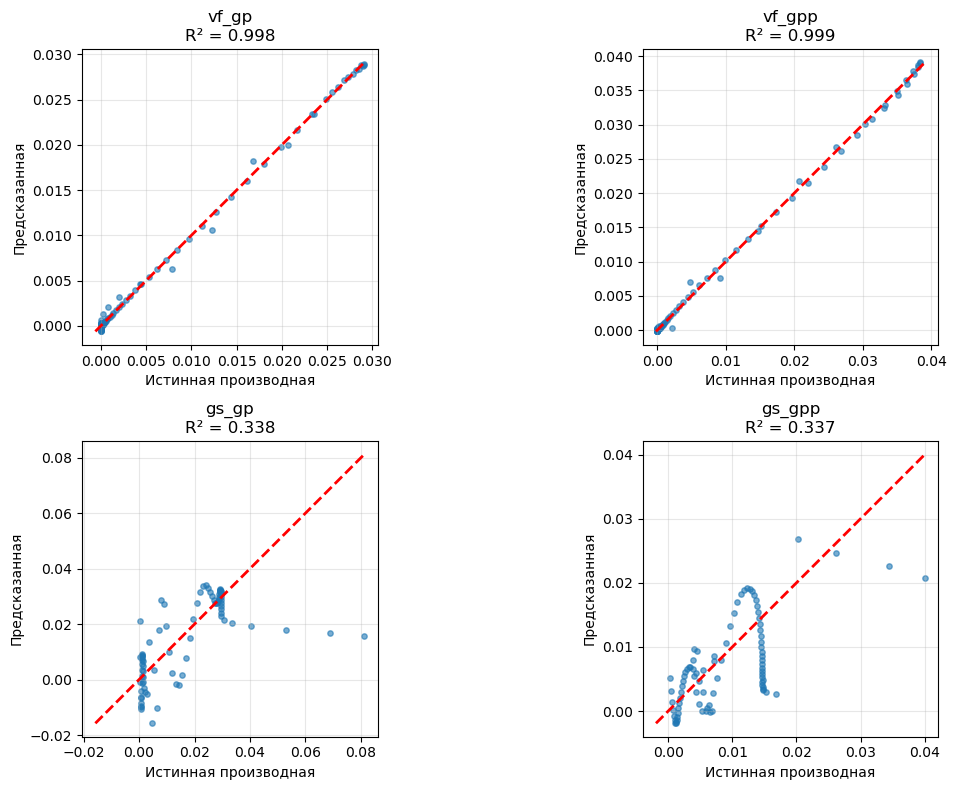

In [22]:
# =============================================================================
# 7. ВИЗУАЛИЗАЦИЯ (паритет-плот)
# =============================================================================

x_dot_pred = model.predict(X_scaled)  # встроенный метод вместо theta @ coefficients

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for idx, (ax, var) in enumerate(zip(axes.flat, model.feature_names)):
    active = masks[:, idx]
    ax.scatter(x_dot_scaled[active, idx], x_dot_pred[active, idx], alpha=0.6, s=15)
    lim = [min(x_dot_scaled[active, idx].min(), x_dot_pred[active, idx].min()),
           max(x_dot_scaled[active, idx].max(), x_dot_pred[active, idx].max())]
    ax.plot(lim, lim, 'r--', lw=2)
    r2 = r2_score(x_dot_scaled[active, idx], x_dot_pred[active, idx])
    ax.set_title(f'{var}\nR² = {r2:.3f}')
    ax.set_xlabel('Истинная производная')
    ax.set_ylabel('Предсказанная')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Интегрирование полученной модели

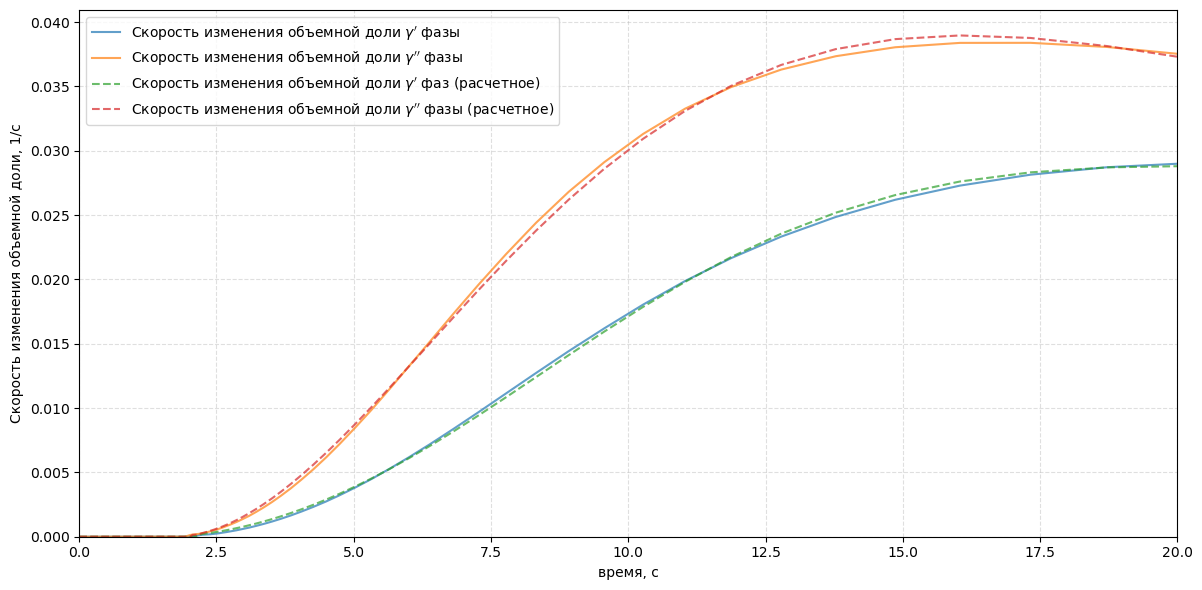

In [12]:
x_dot_pred = model.predict(X_scaled)


plt.figure(figsize=(12, 6))

plt.plot(t, x_dot_scaled[:,0], label=r"Скорость изменения объемной доли $\gamma'$ фазы",  alpha=0.7)
plt.plot(t, x_dot_scaled[:,1], label=r"Скорость изменения объемной доли $\gamma''$ фазы", alpha=0.7)
plt.plot(t, x_dot_pred[:,0], label=r"Скорость изменения объемной доли $\gamma'$ фаз (расчетное)", linestyle='--' , alpha=0.7)
plt.plot(t, x_dot_pred[:,1], label=r"Скорость изменения объемной доли $\gamma''$ фазы (расчетное)",linestyle='--', alpha=0.7)

# Начало осей с 0
plt.xlim(left=0)   # ось X от 0
plt.ylim(bottom=0) # ось Y от 0


plt.xlabel('время, с')
plt.ylabel('Скорость изменения объемной доли, 1/с')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.xlim(0, 20)
plt.show()

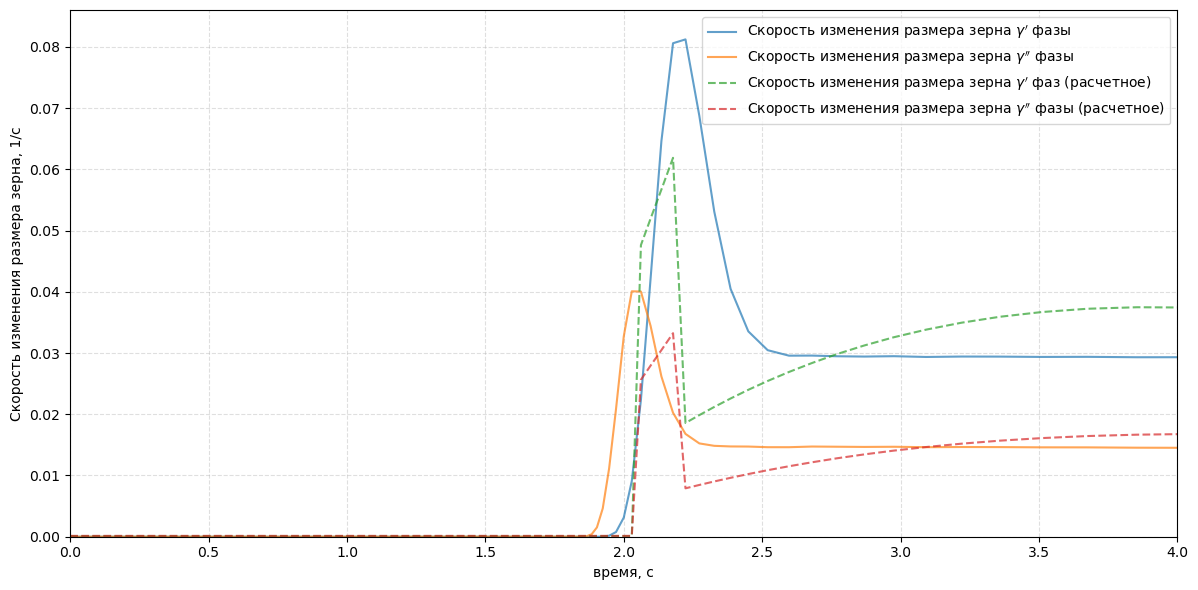

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(t, x_dot_scaled[:,2], label=r"Скорость изменения размера зерна $\gamma'$ фазы",  alpha=0.7)
plt.plot(t, x_dot_scaled[:,3], label=r"Скорость изменения размера зерна $\gamma''$ фазы", alpha=0.7)
plt.plot(t, x_dot_pred[:,2], label=r"Скорость изменения размера зерна $\gamma'$ фаз (расчетное)", linestyle='--' , alpha=0.7)
plt.plot(t, x_dot_pred[:,3], label=r"Скорость изменения размера зерна $\gamma''$ фазы (расчетное)", linestyle='--' , alpha=0.7)

# Начало осей с 0
plt.xlim(left=0)   # ось X от 0
plt.ylim(bottom=0) # ось Y от 0


plt.xlabel('время, с')
plt.ylabel('Скорость изменения размера зерна, 1/с')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.xlim(0, 4)
plt.show()

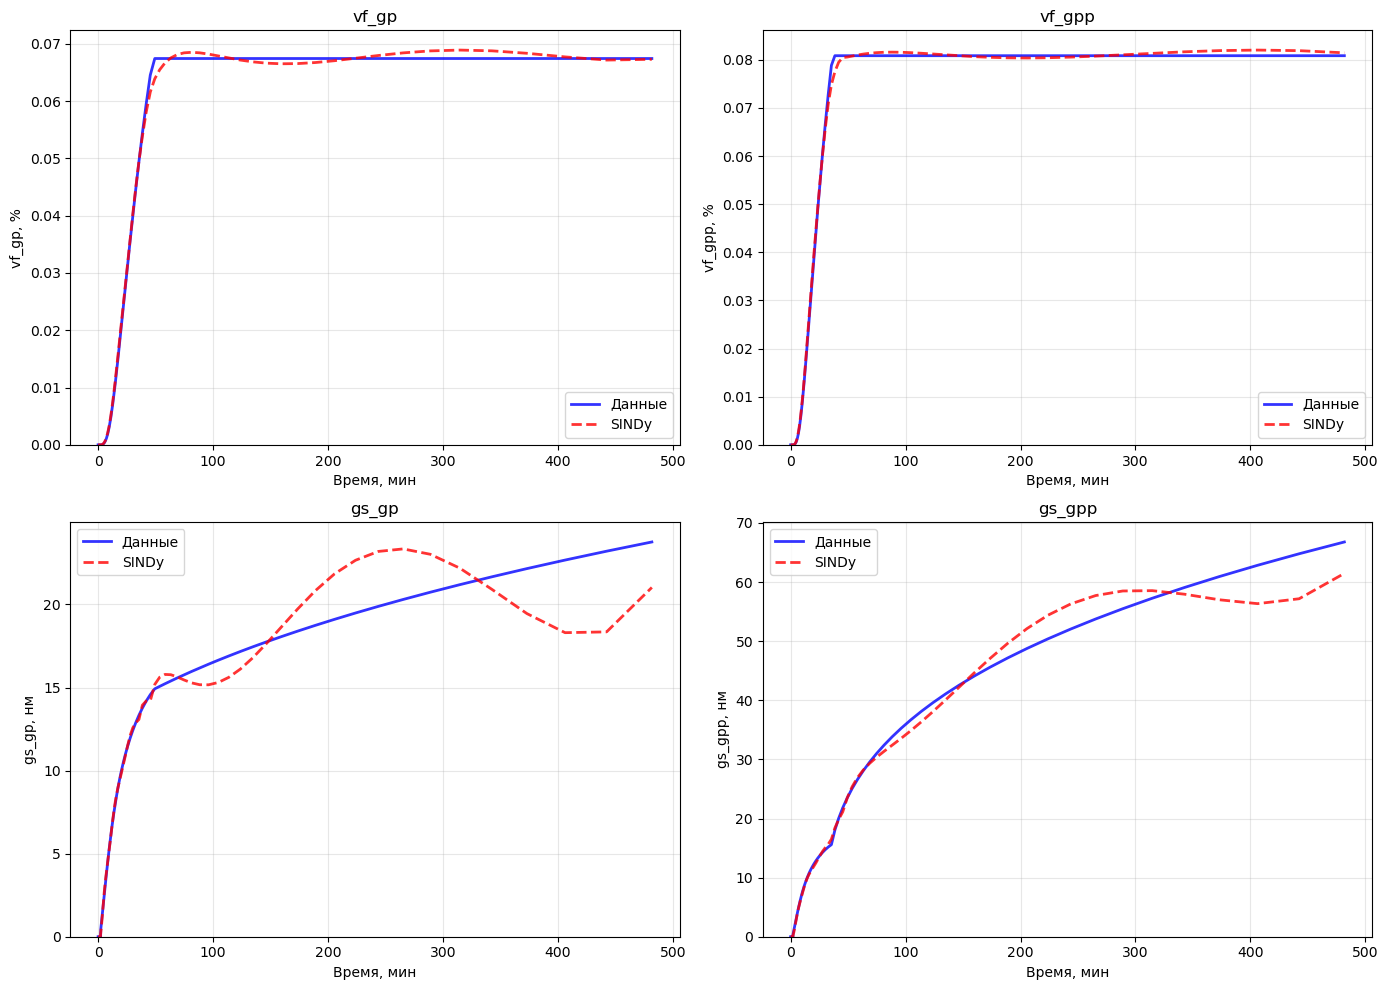

Переменная   |       R²
-------------------------
vf_gp        |   0.9997
vf_gpp       |   0.9998
gs_gp        |   0.9897
gs_gpp       |   0.9959


In [14]:
from scipy.integrate import cumulative_trapezoid


# 1. Интегрирование всех 4 переменных
X_pred_scaled = np.zeros_like(X_scaled)
for i in range(X_scaled.shape[1]):
    # initial=0 добавляет первый элемент, чтобы размер совпадал
    X_pred_scaled[:, i] = cumulative_trapezoid(x_dot_pred[:, i], t, initial=0)

# 2. Обратное масштабирование
X_pred = scaler.inverse_transform(X_pred_scaled)
X_true = scaler.inverse_transform(X_scaled)

# 3. Визуализация
var_names = ['vf_gp', 'vf_gpp', 'gs_gp', 'gs_gpp']
units = ['%', '%', 'нм', 'нм']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, (ax, name, unit) in enumerate(zip(axes.flat, var_names, units)):
    ax.plot(t, X_true[:, idx], 'b-', lw=2, label='Данные', alpha=0.8)
    ax.plot(t, X_pred[:, idx], 'r--', lw=2, label='SINDy', alpha=0.8)
    ax.set_xlabel('Время, мин')
    ax.set_ylabel(f'{name}, {unit}')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# 4. Метрики
print(f"{'Переменная':<12} | {'R²':>8}")
print("-"*25)
for i, var in enumerate(var_names):
    r2 = r2_score(X_true[:, i], X_pred[:, i])
    print(f"{var:<12} | {r2:>8.4f}")

In [15]:
point = -10

In [16]:
X_scaled[point]

array([0.9999    , 0.9999    , 0.81999162, 0.754598  ])

In [17]:
x_dot_scaled[point]

array([3.46944695e-18, 0.00000000e+00, 8.64719444e-04, 1.30005313e-03])

In [18]:
masks[point]

array([ True,  True,  True,  True])

In [19]:
smooth = savgol_filter(X_scaled[:, 3], window_length=5, polyorder=2)
smooth

array([1.00000000e-04, 1.00000000e-04, 1.00000000e-04, ...,
       9.40816904e-01, 9.70005474e-01, 9.99894397e-01], shape=(1121,))

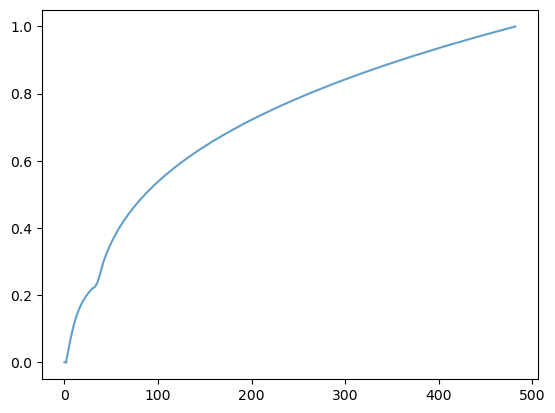

In [20]:
plt.plot(t, smooth , label=r"Скорость изменения размера зерна $\gamma'$ фазы",  alpha=0.7)